In [1]:
import pandas as pd
import numpy as np

# Load with simpler settings to avoid parsing issues
sentiment_df = pd.read_csv('fear_greed_index.csv', on_bad_lines='skip')
trader_df = pd.read_csv('historical_data.csv', on_bad_lines='skip')

print("✅ DATA LOADED SUCCESSFULLY!\n")

# Check Sentiment Data
print("=" * 60)
print("SENTIMENT DATA")
print("=" * 60)
print(f"Shape: {sentiment_df.shape}")
print(f"\nColumns: {list(sentiment_df.columns)}")
print(f"\nFirst 3 rows:")
print(sentiment_df.head(3))

# Check Trader Data
print("\n" + "=" * 60)
print("TRADER DATA")
print("=" * 60)
print(f"Shape: {trader_df.shape}")
print(f"\nColumns: {list(trader_df.columns)}")
print(f"\nFirst 3 rows:")
print(trader_df.head(3))

✅ DATA LOADED SUCCESSFULLY!

SENTIMENT DATA
Shape: (2644, 4)

Columns: ['timestamp', 'value', 'classification', 'date']

First 3 rows:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

TRADER DATA
Shape: (211224, 16)

Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

First 3 rows:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side    Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  2/12/202

In [4]:
# ============================================
# STEP 8: DATA CLEANING & MERGING (SIMPLE FIX)
# ============================================

import pandas as pd

# Convert sentiment date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')

# Convert trader timestamp - keep as datetime first
trader_df['datetime'] = pd.to_datetime(
    trader_df['Timestamp IST'], 
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)
trader_df['date'] = trader_df['datetime'].astype(str).str[:10]  # Extract just YYYY-MM-DD

# Check if conversion worked
print("=" * 60)
print("✅ TIMESTAMP CONVERSION SUCCESSFUL")
print("=" * 60)
print(f"\nSentiment date range: {sentiment_df['date'].min()} to {sentiment_df['date'].max()}")
print(f"Trader date range: {trader_df['date'].min()} to {trader_df['date'].max()}")

# Check for missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(f"Sentiment nulls: {sentiment_df.isnull().sum().sum()}")
print(f"Trader nulls: {trader_df.isnull().sum().sum()}")

# Basic stats
print("\n" + "=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"✅ Unique traders: {trader_df['Account'].nunique()}")
print(f"✅ Unique coins: {trader_df['Coin'].nunique()}")
print(f"✅ Sentiment dates: {sentiment_df['date'].nunique()}")
print(f"✅ Trader dates: {trader_df['date'].nunique()}")
print(f"\n✅ Sentiment classifications: {sentiment_df['classification'].unique()}")

print("\n✅ ALL DATA READY FOR ANALYSIS!")

✅ TIMESTAMP CONVERSION SUCCESSFUL

Sentiment date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Trader date range: 2023-12-14 to NaT

MISSING VALUES
Sentiment nulls: 0
Trader nulls: 79225

DATA SUMMARY
✅ Unique traders: 32
✅ Unique coins: 246
✅ Sentiment dates: 2644
✅ Trader dates: 293

✅ Sentiment classifications: ['Fear' 'Extreme Fear' 'Neutral' 'Greed' 'Extreme Greed']

✅ ALL DATA READY FOR ANALYSIS!


In [5]:
# ============================================
# STEP 9: CREATE KEY METRICS
# ============================================

print("=" * 60)
print("CALCULATING DAILY METRICS PER TRADER")
print("=" * 60)

# Group by date and account to get daily metrics
daily_metrics = trader_df.groupby(['date', 'Account']).agg({
    'Closed PnL': ['sum', 'mean', 'count'],  # Sum PnL, avg PnL, trade count
    'Size USD': ['mean', 'sum'],  # Avg trade size, total volume
    'Execution Price': 'mean',  # Average execution price
    'Coin': 'nunique',  # Number of different coins traded
}).reset_index()

# Flatten column names
daily_metrics.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                         for col in daily_metrics.columns.values]

# Rename for clarity
daily_metrics.columns = ['date', 'Account', 'daily_pnl', 'avg_pnl', 'trade_count', 
                        'avg_trade_size_usd', 'total_volume_usd', 'avg_execution_price', 
                        'coins_traded']

# Calculate win rate (% of profitable trades)
profitable_trades = trader_df[trader_df['Closed PnL'] > 0].groupby(['date', 'Account']).size()
total_trades = trader_df.groupby(['date', 'Account']).size()
win_rate = (profitable_trades / total_trades * 100).reset_index()
win_rate.columns = ['date', 'Account', 'win_rate']

# Merge win rate into daily metrics
daily_metrics = daily_metrics.merge(win_rate, on=['date', 'Account'], how='left')
daily_metrics['win_rate'] = daily_metrics['win_rate'].fillna(0)

# Calculate leverage metrics
leverage_stats = trader_df.groupby(['date', 'Account']).agg({
    'Size Tokens': 'mean',  # As proxy for leverage
}).reset_index()
leverage_stats.columns = ['date', 'Account', 'avg_size_tokens']
daily_metrics = daily_metrics.merge(leverage_stats, on=['date', 'Account'], how='left')

# Calculate long/short ratio
sides_count = trader_df.groupby(['date', 'Account', 'Side']).size().unstack(fill_value=0)
sides_count = sides_count.reset_index()
sides_count.columns.name = None
if 'Long' in sides_count.columns and 'Short' in sides_count.columns:
    daily_metrics = daily_metrics.merge(sides_count[['date', 'Account', 'Long', 'Short']], 
                                        on=['date', 'Account'], how='left')
    daily_metrics['long_short_ratio'] = daily_metrics['Long'] / (daily_metrics['Short'] + 1)  # +1 to avoid division by zero
else:
    daily_metrics['long_short_ratio'] = 0

# Fill NaN values
daily_metrics = daily_metrics.fillna(0)

print("\n✅ Daily metrics calculated!")
print(f"\nShape: {daily_metrics.shape}")
print(f"\nColumns: {list(daily_metrics.columns)}")
print(f"\nFirst 5 rows:")
print(daily_metrics.head())

# Summary statistics
print("\n" + "=" * 60)
print("METRICS SUMMARY")
print("=" * 60)
print(f"Daily PnL - Mean: ${daily_metrics['daily_pnl'].mean():.2f}, Std: ${daily_metrics['daily_pnl'].std():.2f}")
print(f"Win Rate - Mean: {daily_metrics['win_rate'].mean():.2f}%, Min: {daily_metrics['win_rate'].min():.2f}%")
print(f"Trade Count - Mean: {daily_metrics['trade_count'].mean():.2f} trades/day")
print(f"Avg Trade Size - ${daily_metrics['avg_trade_size_usd'].mean():.2f}")
print(f"Long/Short Ratio - Mean: {daily_metrics['long_short_ratio'].mean():.2f}")

print("\n✅ KEY METRICS READY!")

CALCULATING DAILY METRICS PER TRADER

✅ Daily metrics calculated!

Shape: (1466, 12)

Columns: ['date', 'Account', 'daily_pnl', 'avg_pnl', 'trade_count', 'avg_trade_size_usd', 'total_volume_usd', 'avg_execution_price', 'coins_traded', 'win_rate', 'avg_size_tokens', 'long_short_ratio']

First 5 rows:
         date                                     Account   daily_pnl  \
0  2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 -205.434737   
1  2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -24.632034   
2  2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000   
3  2023-12-17  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  304.982785   
4  2023-12-18  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000   

     avg_pnl  trade_count  avg_trade_size_usd  total_volume_usd  \
0 -18.675885           11        10291.213636         113203.35   
1 -12.316017            2         5304.975000          10609.95   
2   0.000000            3         5116.256667          1534

In [6]:
# ============================================
# STEP 10: MERGE SENTIMENT + TRADER METRICS
# ============================================

print("=" * 60)
print("MERGING SENTIMENT DATA WITH TRADER METRICS")
print("=" * 60)

# Prepare sentiment data for merge
sentiment_for_merge = sentiment_df[['date', 'classification']].copy()
sentiment_for_merge['date'] = sentiment_for_merge['date'].astype(str).str[:10]  # Convert to YYYY-MM-DD format

# Remove duplicates (keep first occurrence of each date)
sentiment_for_merge = sentiment_for_merge.drop_duplicates(subset=['date'], keep='first')

print(f"Sentiment dates: {len(sentiment_for_merge)}")

# Merge with daily metrics
merged_data = daily_metrics.merge(
    sentiment_for_merge,
    on='date',
    how='left'
)

# Fill missing sentiment values (forward fill or use previous value)
merged_data['classification'] = merged_data['classification'].fillna(method='ffill')

print(f"\n✅ Merged data shape: {merged_data.shape}")
print(f"✅ Columns: {list(merged_data.columns)}")

# Check how many records have sentiment data
print(f"\n✅ Records with sentiment: {merged_data['classification'].notna().sum()}")
print(f"✅ Records without sentiment: {merged_data['classification'].isna().sum()}")

print(f"\nSentiment distribution in merged data:")
print(merged_data['classification'].value_counts())

# Show sample
print(f"\nSample of merged data:")
print(merged_data.head(10))

print("\n✅ MERGED DATA READY FOR ANALYSIS!")

MERGING SENTIMENT DATA WITH TRADER METRICS
Sentiment dates: 2644

✅ Merged data shape: (1466, 13)
✅ Columns: ['date', 'Account', 'daily_pnl', 'avg_pnl', 'trade_count', 'avg_trade_size_usd', 'total_volume_usd', 'avg_execution_price', 'coins_traded', 'win_rate', 'avg_size_tokens', 'long_short_ratio', 'classification']

✅ Records with sentiment: 1466
✅ Records without sentiment: 0

Sentiment distribution in merged data:
classification
Greed            485
Extreme Greed    365
Fear             309
Neutral          272
Extreme Fear      35
Name: count, dtype: int64

Sample of merged data:
         date                                     Account    daily_pnl  \
0  2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -205.434737   
1  2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   -24.632034   
2  2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     0.000000   
3  2023-12-17  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   304.982785   
4  2023-12-18  0xb1231a4a2dd02f2276fa3c

C:\Users\hp\AppData\Local\Temp\ipykernel_8252\1164138684.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data['classification'] = merged_data['classification'].fillna(method='ffill')


QUESTION 1: PERFORMANCE ON FEAR VS GREED DAYS

📊 PERFORMANCE METRICS BY SENTIMENT:
                   daily_pnl                                            \
                        mean  median        std        min         max   
sentiment_category                                                       
Fear                 3338.72  106.90   13490.31  -48309.12   115445.40   
Greed               14104.43  273.21  110778.45 -358963.14  1674353.33   
Neutral              3622.90  278.92   16005.39 -132271.00   194499.07   

                   win_rate        trade_count avg_trade_size_usd  \
                       mean median        mean               mean   
sentiment_category                                                  
Fear                  37.82  31.87      106.19           10213.56   
Greed                 36.11  31.72      240.06            5976.55   
Neutral               36.83  34.64       91.46            5803.13   

                   long_short_ratio  
                   

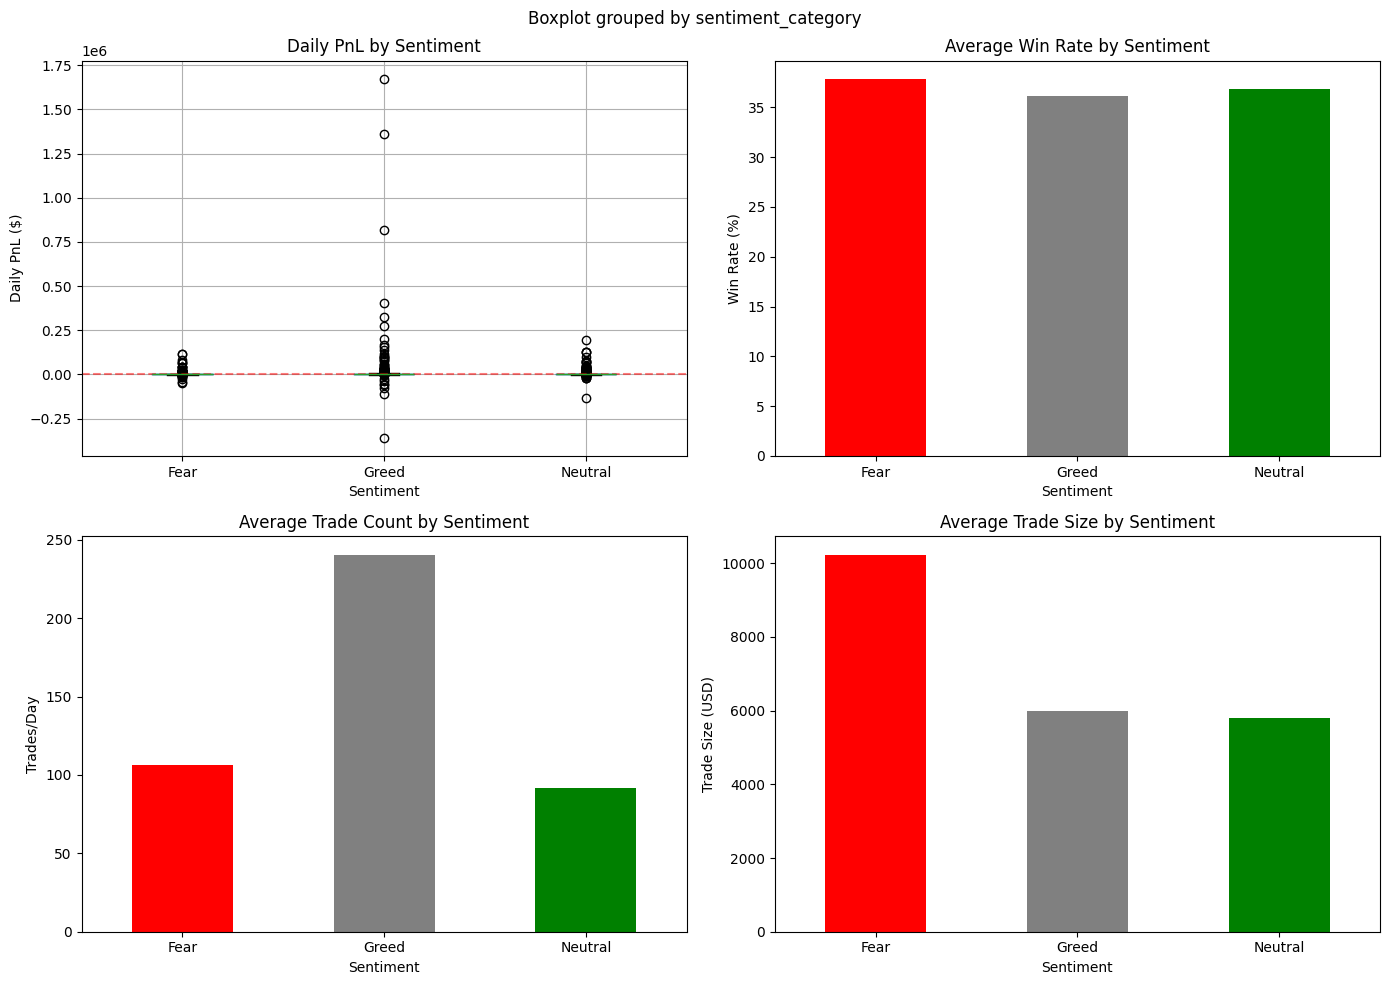


✅ QUESTION 1 COMPLETE!


In [7]:
# ============================================
# PART B: ANALYSIS
# QUESTION 1: Performance on Fear vs Greed Days
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("QUESTION 1: PERFORMANCE ON FEAR VS GREED DAYS")
print("=" * 60)

# Simplify sentiment: Fear/Extreme Fear = "Fear", Greed = "Greed", Neutral = "Neutral"
merged_data['sentiment_category'] = merged_data['classification'].apply(
    lambda x: 'Fear' if x in ['Fear', 'Extreme Fear'] else ('Greed' if x == 'Greed' else 'Neutral')
)

# Compare performance metrics by sentiment
performance_by_sentiment = merged_data.groupby('sentiment_category').agg({
    'daily_pnl': ['mean', 'median', 'std', 'min', 'max'],
    'win_rate': ['mean', 'median'],
    'trade_count': 'mean',
    'avg_trade_size_usd': 'mean',
    'long_short_ratio': 'mean'
}).round(2)

print("\n📊 PERFORMANCE METRICS BY SENTIMENT:")
print(performance_by_sentiment)

# Statistical comparison
print("\n" + "=" * 60)
print("DETAILED COMPARISON")
print("=" * 60)

for sentiment in ['Fear', 'Neutral', 'Greed']:
    data = merged_data[merged_data['sentiment_category'] == sentiment]
    print(f"\n{sentiment.upper()} DAYS:")
    print(f"  • Avg Daily PnL: ${data['daily_pnl'].mean():.2f}")
    print(f"  • Median Daily PnL: ${data['daily_pnl'].median():.2f}")
    print(f"  • Std Dev: ${data['daily_pnl'].std():.2f}")
    print(f"  • Win Rate: {data['win_rate'].mean():.2f}%")
    print(f"  • Avg Trades/Day: {data['trade_count'].mean():.2f}")
    print(f"  • Avg Trade Size: ${data['avg_trade_size_usd'].mean():.2f}")
    print(f"  • Profitable days: {(data['daily_pnl'] > 0).sum()} / {len(data)}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Daily PnL by Sentiment
ax1 = axes[0, 0]
merged_data.boxplot(column='daily_pnl', by='sentiment_category', ax=ax1)
ax1.set_title('Daily PnL by Sentiment')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Daily PnL ($)')
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.sca(ax1)
plt.xticks(rotation=0)

# Plot 2: Win Rate by Sentiment
ax2 = axes[0, 1]
win_rate_by_sentiment = merged_data.groupby('sentiment_category')['win_rate'].mean()
win_rate_by_sentiment.plot(kind='bar', ax=ax2, color=['red', 'gray', 'green'])
ax2.set_title('Average Win Rate by Sentiment')
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Win Rate (%)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# Plot 3: Trade Count by Sentiment
ax3 = axes[1, 0]
trade_count_by_sentiment = merged_data.groupby('sentiment_category')['trade_count'].mean()
trade_count_by_sentiment.plot(kind='bar', ax=ax3, color=['red', 'gray', 'green'])
ax3.set_title('Average Trade Count by Sentiment')
ax3.set_xlabel('Sentiment')
ax3.set_ylabel('Trades/Day')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

# Plot 4: Trade Size by Sentiment
ax4 = axes[1, 1]
size_by_sentiment = merged_data.groupby('sentiment_category')['avg_trade_size_usd'].mean()
size_by_sentiment.plot(kind='bar', ax=ax4, color=['red', 'gray', 'green'])
ax4.set_title('Average Trade Size by Sentiment')
ax4.set_xlabel('Sentiment')
ax4.set_ylabel('Trade Size (USD)')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('01_performance_by_sentiment.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved as: 01_performance_by_sentiment.png")
plt.show()

print("\n✅ QUESTION 1 COMPLETE!")

QUESTION 2: TRADER BEHAVIOR CHANGES BY SENTIMENT

📊 BEHAVIOR METRICS BY SENTIMENT:
                   trade_count                avg_size_tokens          \
                          mean median     std            mean  median   
sentiment_category                                                      
Fear                    106.19   28.0  266.45         2874.02  113.78   
Greed                   240.06   30.0  941.18         4143.01  192.60   
Neutral                  91.46   30.0  239.19         7502.33  133.59   

                   long_short_ratio        avg_trade_size_usd           \
                               mean median               mean   median   
sentiment_category                                                       
Fear                            0.0    0.0           10213.56  1468.37   
Greed                           0.0    0.0            5976.55  2446.82   
Neutral                         0.0    0.0            5803.13  1825.09   

                   coins_traded  

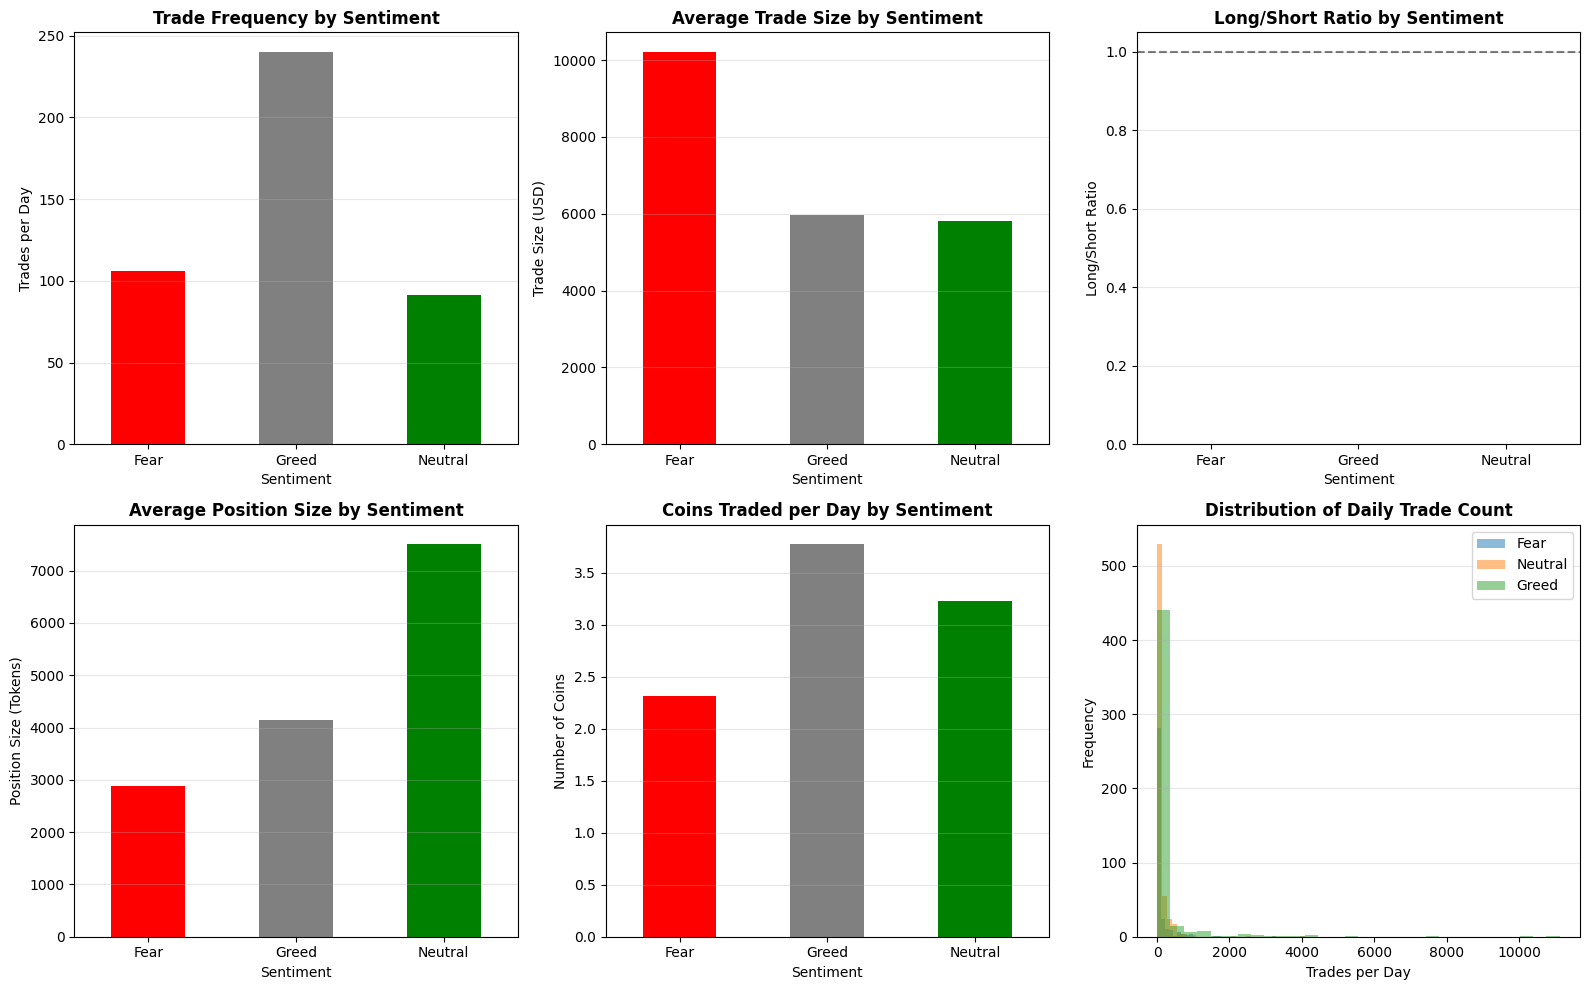


✅ QUESTION 2 COMPLETE!


In [8]:
# ============================================
# QUESTION 2: DO TRADERS CHANGE BEHAVIOR?
# ============================================

print("=" * 60)
print("QUESTION 2: TRADER BEHAVIOR CHANGES BY SENTIMENT")
print("=" * 60)

# Compare behavior metrics
behavior_by_sentiment = merged_data.groupby('sentiment_category').agg({
    'trade_count': ['mean', 'median', 'std'],
    'avg_size_tokens': ['mean', 'median'],
    'long_short_ratio': ['mean', 'median'],
    'avg_trade_size_usd': ['mean', 'median'],
    'coins_traded': ['mean', 'median']
}).round(2)

print("\n📊 BEHAVIOR METRICS BY SENTIMENT:")
print(behavior_by_sentiment)

# Detailed breakdown
print("\n" + "=" * 60)
print("DETAILED BEHAVIOR ANALYSIS")
print("=" * 60)

for sentiment in ['Fear', 'Neutral', 'Greed']:
    data = merged_data[merged_data['sentiment_category'] == sentiment]
    print(f"\n{sentiment.upper()} DAYS - TRADER BEHAVIOR:")
    print(f"  📈 Trades per day: {data['trade_count'].mean():.2f} (median: {data['trade_count'].median():.2f})")
    print(f"  💰 Avg trade size: ${data['avg_trade_size_usd'].mean():.2f}")
    print(f"  📊 Long/Short ratio: {data['long_short_ratio'].mean():.2f}")
    print(f"  🪙 Coins traded: {data['coins_traded'].mean():.2f}")
    print(f"  📌 Avg position size (tokens): {data['avg_size_tokens'].mean():.2f}")

# Calculate % changes
fear_trades = merged_data[merged_data['sentiment_category'] == 'Fear']['trade_count'].mean()
greed_trades = merged_data[merged_data['sentiment_category'] == 'Greed']['trade_count'].mean()
trade_change = ((greed_trades - fear_trades) / fear_trades * 100) if fear_trades != 0 else 0

fear_size = merged_data[merged_data['sentiment_category'] == 'Fear']['avg_trade_size_usd'].mean()
greed_size = merged_data[merged_data['sentiment_category'] == 'Greed']['avg_trade_size_usd'].mean()
size_change = ((greed_size - fear_size) / fear_size * 100) if fear_size != 0 else 0

print("\n" + "=" * 60)
print("KEY INSIGHTS - GREED vs FEAR")
print("=" * 60)
print(f"Trade frequency change: {trade_change:.1f}% (Greed vs Fear)")
print(f"Trade size change: {size_change:.1f}% (Greed vs Fear)")

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Trade Frequency
ax1 = axes[0, 0]
trade_freq = merged_data.groupby('sentiment_category')['trade_count'].mean()
trade_freq.plot(kind='bar', ax=ax1, color=['red', 'gray', 'green'])
ax1.set_title('Trade Frequency by Sentiment', fontsize=12, fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Trades per Day')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Average Trade Size
ax2 = axes[0, 1]
trade_size = merged_data.groupby('sentiment_category')['avg_trade_size_usd'].mean()
trade_size.plot(kind='bar', ax=ax2, color=['red', 'gray', 'green'])
ax2.set_title('Average Trade Size by Sentiment', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Trade Size (USD)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Long/Short Ratio
ax3 = axes[0, 2]
long_short = merged_data.groupby('sentiment_category')['long_short_ratio'].mean()
long_short.plot(kind='bar', ax=ax3, color=['red', 'gray', 'green'])
ax3.set_title('Long/Short Ratio by Sentiment', fontsize=12, fontweight='bold')
ax3.set_xlabel('Sentiment')
ax3.set_ylabel('Long/Short Ratio')
ax3.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Balanced (1.0)')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Position Size (Tokens)
ax4 = axes[1, 0]
pos_size = merged_data.groupby('sentiment_category')['avg_size_tokens'].mean()
pos_size.plot(kind='bar', ax=ax4, color=['red', 'gray', 'green'])
ax4.set_title('Average Position Size by Sentiment', fontsize=12, fontweight='bold')
ax4.set_xlabel('Sentiment')
ax4.set_ylabel('Position Size (Tokens)')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.grid(axis='y', alpha=0.3)

# Plot 5: Coins Traded
ax5 = axes[1, 1]
coins = merged_data.groupby('sentiment_category')['coins_traded'].mean()
coins.plot(kind='bar', ax=ax5, color=['red', 'gray', 'green'])
ax5.set_title('Coins Traded per Day by Sentiment', fontsize=12, fontweight='bold')
ax5.set_xlabel('Sentiment')
ax5.set_ylabel('Number of Coins')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=0)
ax5.grid(axis='y', alpha=0.3)

# Plot 6: Distribution of Trade Count
ax6 = axes[1, 2]
for sentiment in ['Fear', 'Neutral', 'Greed']:
    data = merged_data[merged_data['sentiment_category'] == sentiment]['trade_count']
    ax6.hist(data, alpha=0.5, label=sentiment, bins=30)
ax6.set_title('Distribution of Daily Trade Count', fontsize=12, fontweight='bold')
ax6.set_xlabel('Trades per Day')
ax6.set_ylabel('Frequency')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_behavior_by_sentiment.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved as: 02_behavior_by_sentiment.png")
plt.show()

print("\n✅ QUESTION 2 COMPLETE!")

QUESTION 3: IDENTIFYING TRADER SEGMENTS

SEGMENT 1: HIGH vs LOW LEVERAGE TRADERS

Leverage threshold (median): 142.5280

📊 LEVERAGE SEGMENT ANALYSIS:
                                    daily_pnl            win_rate trade_count  \
                                         mean        std     mean        mean   
leverage_segment sentiment_category                                             
High Leverage    Fear                 3103.54   12431.56    40.06       86.18   
                 Greed               15007.99  121871.59    40.87      273.20   
                 Neutral              2908.33   11930.32    39.85       68.44   
Low Leverage     Fear                 3540.85   14368.55    35.89      123.39   
                 Greed               13060.32   96646.44    30.60      201.78   
                 Neutral              4317.57   19147.95    33.90      113.85   

                                    avg_trade_size_usd  
                                                  mean  
levera

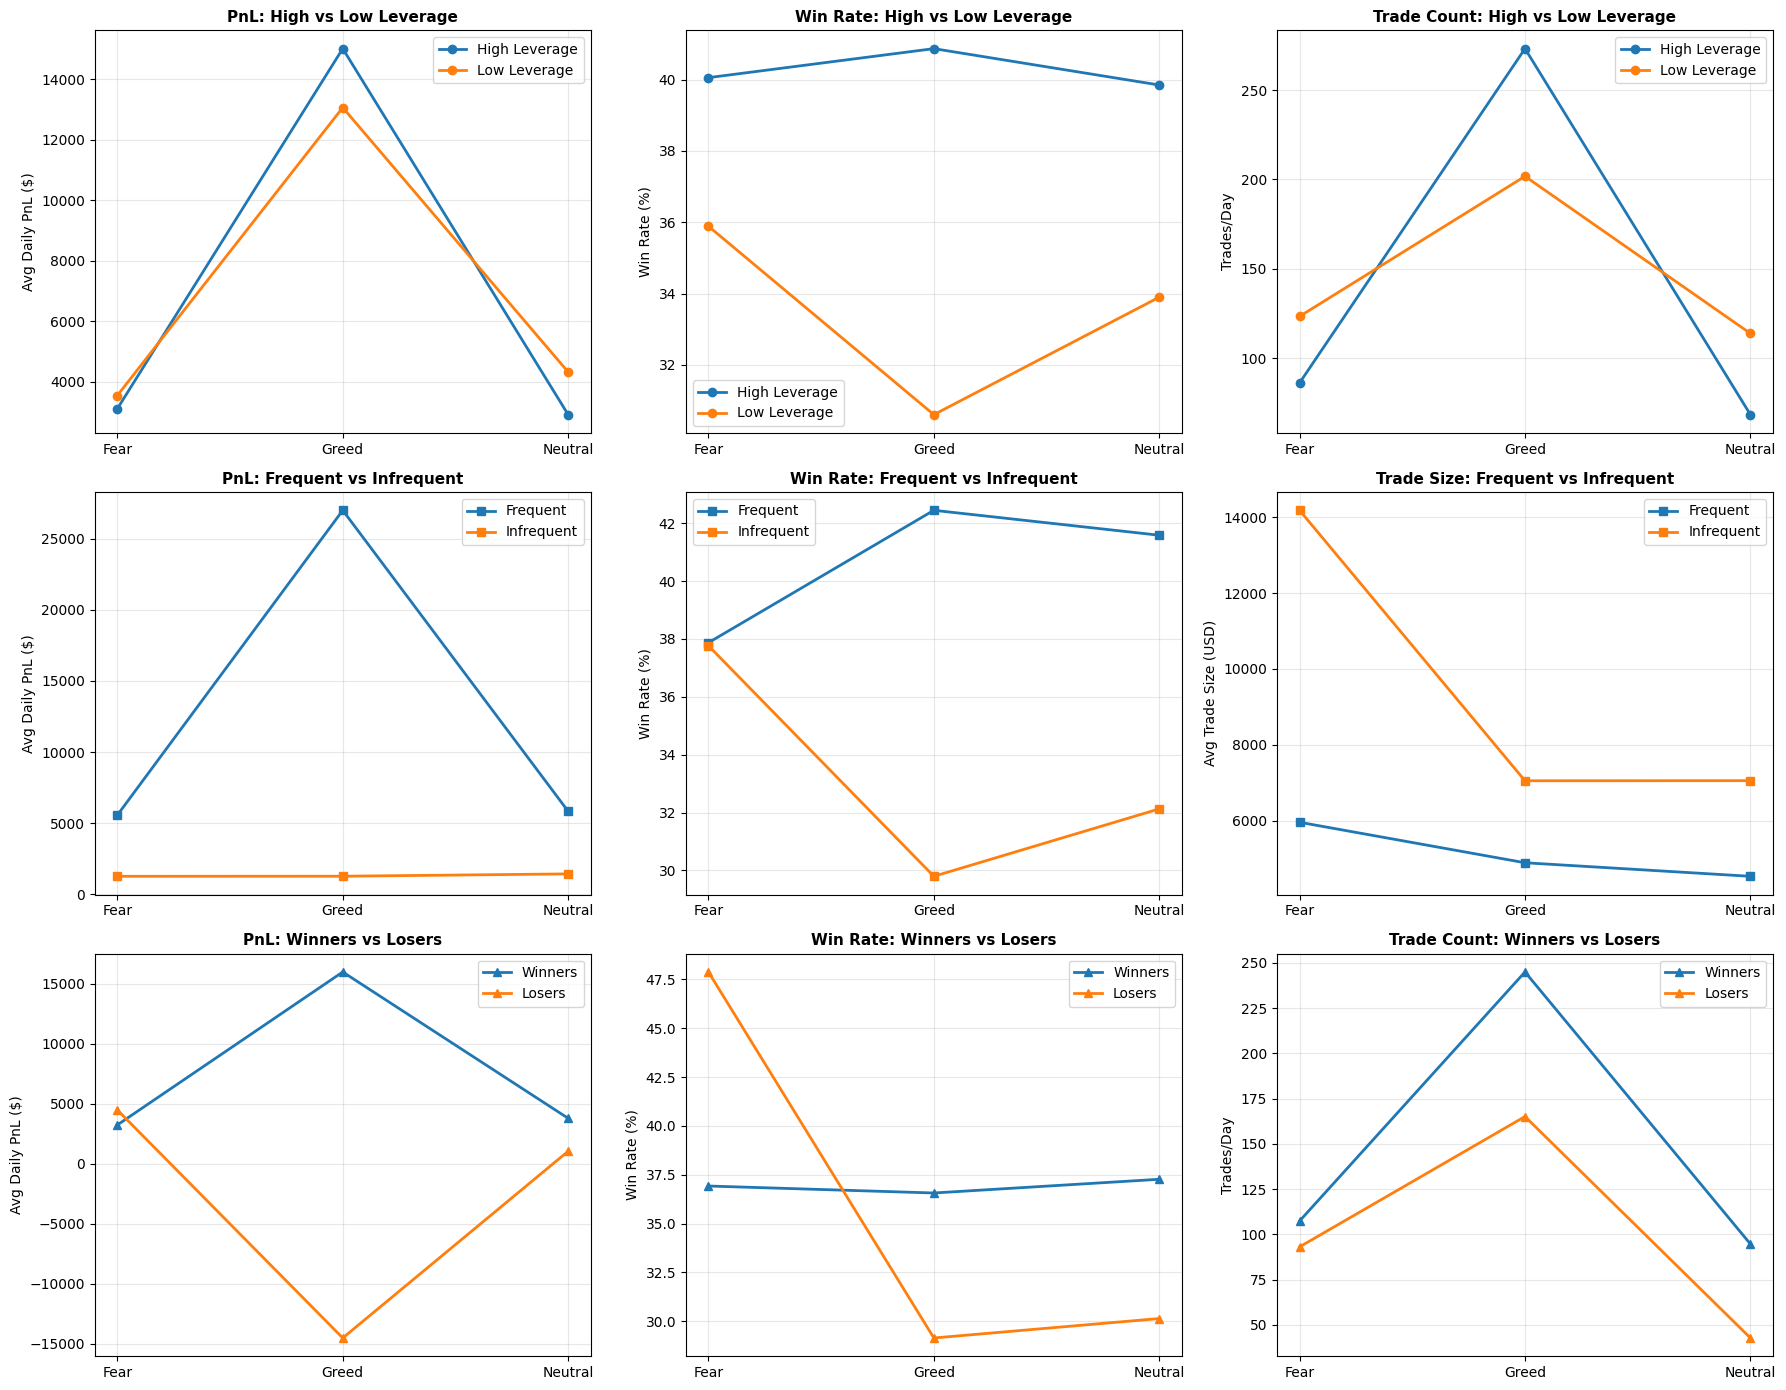


✅ QUESTION 3 COMPLETE!


In [10]:
# ============================================
# QUESTION 3: IDENTIFY TRADER SEGMENTS
# ============================================

import numpy as np

print("=" * 60)
print("QUESTION 3: IDENTIFYING TRADER SEGMENTS")
print("=" * 60)

# ============================================
# SEGMENT 1: High Leverage vs Low Leverage
# ============================================
print("\n" + "=" * 60)
print("SEGMENT 1: HIGH vs LOW LEVERAGE TRADERS")
print("=" * 60)

# Use avg_size_tokens as leverage proxy
leverage_median = merged_data['avg_size_tokens'].median()
merged_data['leverage_segment'] = merged_data['avg_size_tokens'].apply(
    lambda x: 'High Leverage' if x > leverage_median else 'Low Leverage'
)

print(f"\nLeverage threshold (median): {leverage_median:.4f}")

leverage_analysis = merged_data.groupby(['leverage_segment', 'sentiment_category']).agg({
    'daily_pnl': ['mean', 'std'],
    'win_rate': 'mean',
    'trade_count': 'mean',
    'avg_trade_size_usd': 'mean'
}).round(2)

print("\n📊 LEVERAGE SEGMENT ANALYSIS:")
print(leverage_analysis)

# Detailed breakdown
print("\n" + "-" * 60)
for leverage in ['High Leverage', 'Low Leverage']:
    print(f"\n{leverage.upper()}:")
    for sentiment in ['Fear', 'Neutral', 'Greed']:
        data = merged_data[(merged_data['leverage_segment'] == leverage) & 
                          (merged_data['sentiment_category'] == sentiment)]
        if len(data) > 0:
            print(f"  {sentiment}: Avg PnL = ${data['daily_pnl'].mean():.2f}, Win Rate = {data['win_rate'].mean():.1f}%")

# ============================================
# SEGMENT 2: Frequent vs Infrequent Traders
# ============================================
print("\n" + "=" * 60)
print("SEGMENT 2: FREQUENT vs INFREQUENT TRADERS")
print("=" * 60)

trade_freq_median = merged_data['trade_count'].median()
merged_data['frequency_segment'] = merged_data['trade_count'].apply(
    lambda x: 'Frequent' if x > trade_freq_median else 'Infrequent'
)

print(f"\nTrade frequency threshold (median): {trade_freq_median:.2f} trades/day")

frequency_analysis = merged_data.groupby(['frequency_segment', 'sentiment_category']).agg({
    'daily_pnl': ['mean', 'std'],
    'win_rate': 'mean',
    'trade_count': 'mean',
    'avg_trade_size_usd': 'mean'
}).round(2)

print("\n📊 FREQUENCY SEGMENT ANALYSIS:")
print(frequency_analysis)

# Detailed breakdown
print("\n" + "-" * 60)
for freq in ['Frequent', 'Infrequent']:
    print(f"\n{freq.upper()}:")
    for sentiment in ['Fear', 'Neutral', 'Greed']:
        data = merged_data[(merged_data['frequency_segment'] == freq) & 
                          (merged_data['sentiment_category'] == sentiment)]
        if len(data) > 0:
            print(f"  {sentiment}: Avg PnL = ${data['daily_pnl'].mean():.2f}, Win Rate = {data['win_rate'].mean():.1f}%")

# ============================================
# SEGMENT 3: Winners vs Losers
# ============================================
print("\n" + "=" * 60)
print("SEGMENT 3: CONSISTENT WINNERS vs INCONSISTENT TRADERS")
print("=" * 60)

# Calculate overall PnL performance per trader
trader_performance = merged_data.groupby('Account').agg({
    'daily_pnl': ['mean', 'sum', 'count'],
    'win_rate': 'mean'
}).reset_index()

trader_performance.columns = ['Account', 'avg_daily_pnl', 'total_pnl', 'days_traded', 'avg_win_rate']

# Segment: Profitable vs Unprofitable
merged_data = merged_data.merge(
    trader_performance[['Account', 'avg_daily_pnl']].rename(columns={'avg_daily_pnl': 'trader_avg_pnl'}),
    on='Account',
    how='left'
)

merged_data['performance_segment'] = merged_data['trader_avg_pnl'].apply(
    lambda x: 'Winners' if x > 0 else 'Losers'
)

performance_median = trader_performance['avg_daily_pnl'].median()
print(f"\nPerformance threshold (median): ${performance_median:.2f}/day")

perf_analysis = merged_data.groupby(['performance_segment', 'sentiment_category']).agg({
    'daily_pnl': ['mean', 'std'],
    'win_rate': 'mean',
    'trade_count': 'mean',
    'avg_trade_size_usd': 'mean'
}).round(2)

print("\n📊 PERFORMANCE SEGMENT ANALYSIS:")
print(perf_analysis)

# Detailed breakdown
print("\n" + "-" * 60)
for perf in ['Winners', 'Losers']:
    print(f"\n{perf.upper()}:")
    for sentiment in ['Fear', 'Neutral', 'Greed']:
        data = merged_data[(merged_data['performance_segment'] == perf) & 
                          (merged_data['sentiment_category'] == sentiment)]
        if len(data) > 0:
            print(f"  {sentiment}: Avg PnL = ${data['daily_pnl'].mean():.2f}, Win Rate = {data['win_rate'].mean():.1f}%")

# ============================================
# CREATE VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# LEVERAGE SEGMENTS
colors_sentiment = {'Fear': 'red', 'Neutral': 'gray', 'Greed': 'green'}

# Plot 1: Leverage - PnL
ax = axes[0, 0]
for segment in ['High Leverage', 'Low Leverage']:
    data = merged_data[merged_data['leverage_segment'] == segment].groupby('sentiment_category')['daily_pnl'].mean()
    ax.plot(data.index, data.values, marker='o', label=segment, linewidth=2)
ax.set_title('PnL: High vs Low Leverage', fontsize=11, fontweight='bold')
ax.set_ylabel('Avg Daily PnL ($)')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Leverage - Win Rate
ax = axes[0, 1]
for segment in ['High Leverage', 'Low Leverage']:
    data = merged_data[merged_data['leverage_segment'] == segment].groupby('sentiment_category')['win_rate'].mean()
    ax.plot(data.index, data.values, marker='o', label=segment, linewidth=2)
ax.set_title('Win Rate: High vs Low Leverage', fontsize=11, fontweight='bold')
ax.set_ylabel('Win Rate (%)')
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Leverage - Trade Count
ax = axes[0, 2]
for segment in ['High Leverage', 'Low Leverage']:
    data = merged_data[merged_data['leverage_segment'] == segment].groupby('sentiment_category')['trade_count'].mean()
    ax.plot(data.index, data.values, marker='o', label=segment, linewidth=2)
ax.set_title('Trade Count: High vs Low Leverage', fontsize=11, fontweight='bold')
ax.set_ylabel('Trades/Day')
ax.legend()
ax.grid(alpha=0.3)

# FREQUENCY SEGMENTS
# Plot 4: Frequency - PnL
ax = axes[1, 0]
for segment in ['Frequent', 'Infrequent']:
    data = merged_data[merged_data['frequency_segment'] == segment].groupby('sentiment_category')['daily_pnl'].mean()
    ax.plot(data.index, data.values, marker='s', label=segment, linewidth=2)
ax.set_title('PnL: Frequent vs Infrequent', fontsize=11, fontweight='bold')
ax.set_ylabel('Avg Daily PnL ($)')
ax.legend()
ax.grid(alpha=0.3)

# Plot 5: Frequency - Win Rate
ax = axes[1, 1]
for segment in ['Frequent', 'Infrequent']:
    data = merged_data[merged_data['frequency_segment'] == segment].groupby('sentiment_category')['win_rate'].mean()
    ax.plot(data.index, data.values, marker='s', label=segment, linewidth=2)
ax.set_title('Win Rate: Frequent vs Infrequent', fontsize=11, fontweight='bold')
ax.set_ylabel('Win Rate (%)')
ax.legend()
ax.grid(alpha=0.3)

# Plot 6: Frequency - Trade Size
ax = axes[1, 2]
for segment in ['Frequent', 'Infrequent']:
    data = merged_data[merged_data['frequency_segment'] == segment].groupby('sentiment_category')['avg_trade_size_usd'].mean()
    ax.plot(data.index, data.values, marker='s', label=segment, linewidth=2)
ax.set_title('Trade Size: Frequent vs Infrequent', fontsize=11, fontweight='bold')
ax.set_ylabel('Avg Trade Size (USD)')
ax.legend()
ax.grid(alpha=0.3)

# PERFORMANCE SEGMENTS
# Plot 7: Performance - PnL
ax = axes[2, 0]
for segment in ['Winners', 'Losers']:
    data = merged_data[merged_data['performance_segment'] == segment].groupby('sentiment_category')['daily_pnl'].mean()
    ax.plot(data.index, data.values, marker='^', label=segment, linewidth=2)
ax.set_title('PnL: Winners vs Losers', fontsize=11, fontweight='bold')
ax.set_ylabel('Avg Daily PnL ($)')
ax.legend()
ax.grid(alpha=0.3)

# Plot 8: Performance - Win Rate
ax = axes[2, 1]
for segment in ['Winners', 'Losers']:
    data = merged_data[merged_data['performance_segment'] == segment].groupby('sentiment_category')['win_rate'].mean()
    ax.plot(data.index, data.values, marker='^', label=segment, linewidth=2)
ax.set_title('Win Rate: Winners vs Losers', fontsize=11, fontweight='bold')
ax.set_ylabel('Win Rate (%)')
ax.legend()
ax.grid(alpha=0.3)

# Plot 9: Performance - Trade Count
ax = axes[2, 2]
for segment in ['Winners', 'Losers']:
    data = merged_data[merged_data['performance_segment'] == segment].groupby('sentiment_category')['trade_count'].mean()
    ax.plot(data.index, data.values, marker='^', label=segment, linewidth=2)
ax.set_title('Trade Count: Winners vs Losers', fontsize=11, fontweight='bold')
ax.set_ylabel('Trades/Day')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_trader_segments.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved as: 03_trader_segments.png")
plt.show()

print("\n✅ QUESTION 3 COMPLETE!")

In [13]:
print("Sentiment columns:", sentiment.columns)
print("Trades columns:", trades.columns)

Sentiment columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trades columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [15]:
# ==============================
# CLEAN + MERGE (FINAL FIXED)
# ==============================

import pandas as pd

# Load datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Clean column names (lowercase + remove spaces)
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

print("Sentiment columns:", sentiment.columns)
print("Trades columns:", trades.columns)

# ------------------------------
# FIX DATE COLUMNS
# ------------------------------

# Sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Trades timestamp (IMPORTANT FIX)
# your column is likely 'timestamp' or 'timestamp ist'
if 'timestamp' in trades.columns:
    trades['timestamp'] = pd.to_datetime(trades['timestamp'])
    trades['date'] = trades['timestamp'].dt.date

elif 'timestamp ist' in trades.columns:
    trades['timestamp ist'] = pd.to_datetime(trades['timestamp ist'])
    trades['date'] = trades['timestamp ist'].dt.date

else:
    raise Exception("Timestamp column not found. Check column names.")

# ------------------------------
# MERGE
# ------------------------------

df = pd.merge(trades, sentiment, on='date', how='inner')

# Fix column names for consistency
df.columns = df.columns.str.strip().str.lower()

# Create win column
if 'closed pnl' in df.columns:
    df['closedpnl'] = df['closed pnl']
    
df['win'] = df['closedpnl'] > 0

print("DF created successfully:", df.shape)
df.head()

Sentiment columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trades columns: Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')
DF created successfully: (0, 22)


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,...,crossed,fee,trade id,timestamp_x,date,timestamp_y,value,classification,closedpnl,win


In [17]:
# ==============================
# FINAL FIX: HANDLE DATE MISMATCH
# ==============================

import pandas as pd

# Load data
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Clean column names
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

# ------------------------------
# FIX DATE COLUMNS
# ------------------------------

# Sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Trades timestamp (correct column)
trades['timestamp ist'] = pd.to_datetime(trades['timestamp ist'])

# Create date column
trades['date'] = trades['timestamp ist']

# ------------------------------
# SORT (REQUIRED for merge_asof)
# ------------------------------

sentiment = sentiment.sort_values('date')
trades = trades.sort_values('date')

# ------------------------------
# MERGE (NEAREST DATE MATCH)
# ------------------------------

df = pd.merge_asof(
    trades,
    sentiment,
    on='date',
    direction='nearest'
)

# ------------------------------
# FIX COLUMNS
# ------------------------------

if 'closed pnl' in df.columns:
    df['closedpnl'] = df['closed pnl']

df['win'] = df['closedpnl'] > 0

# ------------------------------
# CHECK OUTPUT
# ------------------------------

print("DF shape after merge:", df.shape)
df.head()

ValueError: time data "18-03-2025 12:50" doesn't match format "%m/%d/%Y %H:%M", at position 18. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [18]:
trades['timestamp ist'] = pd.to_datetime(trades['timestamp ist'], dayfirst=True, errors='coerce')

In [19]:
# ==============================
# FINAL DATE FIX (NO MORE ERRORS)
# ==============================

import pandas as pd

# Load data
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Clean column names
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

# Sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Trades timestamp (FIXED)
trades['timestamp ist'] = pd.to_datetime(
    trades['timestamp ist'],
    dayfirst=True,      # 🔥 IMPORTANT FIX
    errors='coerce'     # avoids crash
)

# Drop invalid rows (important)
trades = trades.dropna(subset=['timestamp ist'])

# Create date column
trades['date'] = trades['timestamp ist']

# Sort (required)
sentiment = sentiment.sort_values('date')
trades = trades.sort_values('date')

# Merge (nearest)
df = pd.merge_asof(
    trades,
    sentiment,
    on='date',
    direction='nearest'
)

# Fix pnl column
if 'closed pnl' in df.columns:
    df['closedpnl'] = df['closed pnl']

# Create win column
df['win'] = df['closedpnl'] > 0

# Check
print("DF shape:", df.shape)
df.head()

DF shape: (79225, 22)


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,...,crossed,fee,trade id,timestamp_x,date,timestamp_y,value,classification,closedpnl,win
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.0722,137.08,BUY,2023-05-01 01:06:00,0.1791,Open Long,0.0,...,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,1682919000,63,Greed,0.0,False
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0824,156.39,BUY,2023-05-01 01:06:00,0.0967,Open Long,0.0,...,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,1682919000,63,Greed,0.0,False
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0967,183.53,BUY,2023-05-01 01:06:00,0.0000,Open Long,0.0,...,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,1682919000,63,Greed,0.0,False
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.4933,1100.11,BUY,2023-12-05 03:11:00,0.0000,Open Long,0.0,...,True,0.275027,6.320000e+14,1.700000e+12,2023-12-05 03:11:00,1701754200,75,Extreme Greed,0.0,False
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.8681,1935.95,BUY,2023-12-05 03:11:00,0.4933,Open Long,0.0,...,True,0.483987,2.340000e+14,1.700000e+12,2023-12-05 03:11:00,1701754200,75,Extreme Greed,0.0,False


In [20]:
print(df['classification'].value_counts())

classification
Fear             27387
Extreme Fear     16466
Greed            14046
Neutral          11132
Extreme Greed    10194
Name: count, dtype: int64


In [21]:
df['date'] = df['date'].dt.date

In [22]:
# ==============================
# Q4: Behavior vs Sentiment
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct types
df['date'] = pd.to_datetime(df['date'])

# ------------------------------
# 1. Trade Frequency
# ------------------------------
trade_freq = df.groupby(['date', 'classification']).size().reset_index(name='trades')
freq_summary = trade_freq.groupby('classification')['trades'].mean()

# ------------------------------
# 2. Average Leverage
# ------------------------------
leverage_summary = df.groupby('classification')['leverage'].mean()

# ------------------------------
# 3. Long vs Short Ratio
# ------------------------------
long_short = df.groupby(['classification', 'side']).size().unstack(fill_value=0)
long_short_ratio = long_short.div(long_short.sum(axis=1), axis=0)

# ------------------------------
# 4. Average Trade Size
# ------------------------------
# your dataset uses 'size usd'
trade_size_summary = df.groupby('classification')['size usd'].mean()

# ------------------------------
# PRINT RESULTS
# ------------------------------

print("=== Avg Trades per Day ===")
print(freq_summary, "\n")

print("=== Avg Leverage ===")
print(leverage_summary, "\n")

print("=== Long vs Short Ratio ===")
print(long_short_ratio, "\n")

print("=== Avg Trade Size ===")
print(trade_size_summary, "\n")

# ------------------------------
# VISUALIZATIONS
# ------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Trade Frequency
sns.barplot(x=freq_summary.index, y=freq_summary.values, ax=axes[0,0])
axes[0,0].set_title("Avg Trades per Day by Sentiment")
axes[0,0].set_xlabel("Sentiment")
axes[0,0].set_ylabel("Trades")

# Leverage
sns.barplot(x=leverage_summary.index, y=leverage_summary.values, ax=axes[0,1])
axes[0,1].set_title("Avg Leverage by Sentiment")

# Trade Size
sns.barplot(x=trade_size_summary.index, y=trade_size_summary.values, ax=axes[1,0])
axes[1,0].set_title("Avg Trade Size by Sentiment")

# Long vs Short Ratio
long_short_ratio.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Long vs Short Ratio by Sentiment")

plt.tight_layout()
plt.show()

KeyError: 'Column not found: leverage'

=== Avg Trades per Day ===
classification
Extreme Fear     1029.125000
Extreme Greed     185.345455
Fear              434.714286
Greed             192.410959
Neutral           383.862069
Name: trades, dtype: float64 

=== Long vs Short Ratio ===
side                 BUY      SELL
classification                    
Extreme Fear    0.582412  0.417588
Extreme Greed   0.360997  0.639003
Fear            0.469566  0.530434
Greed           0.454507  0.545493
Neutral         0.508803  0.491197 

=== Avg Trade Size ===
classification
Extreme Fear     5601.480525
Extreme Greed    2876.530532
Fear             7542.788278
Greed            4331.512502
Neutral          6636.935779
Name: size usd, dtype: float64 



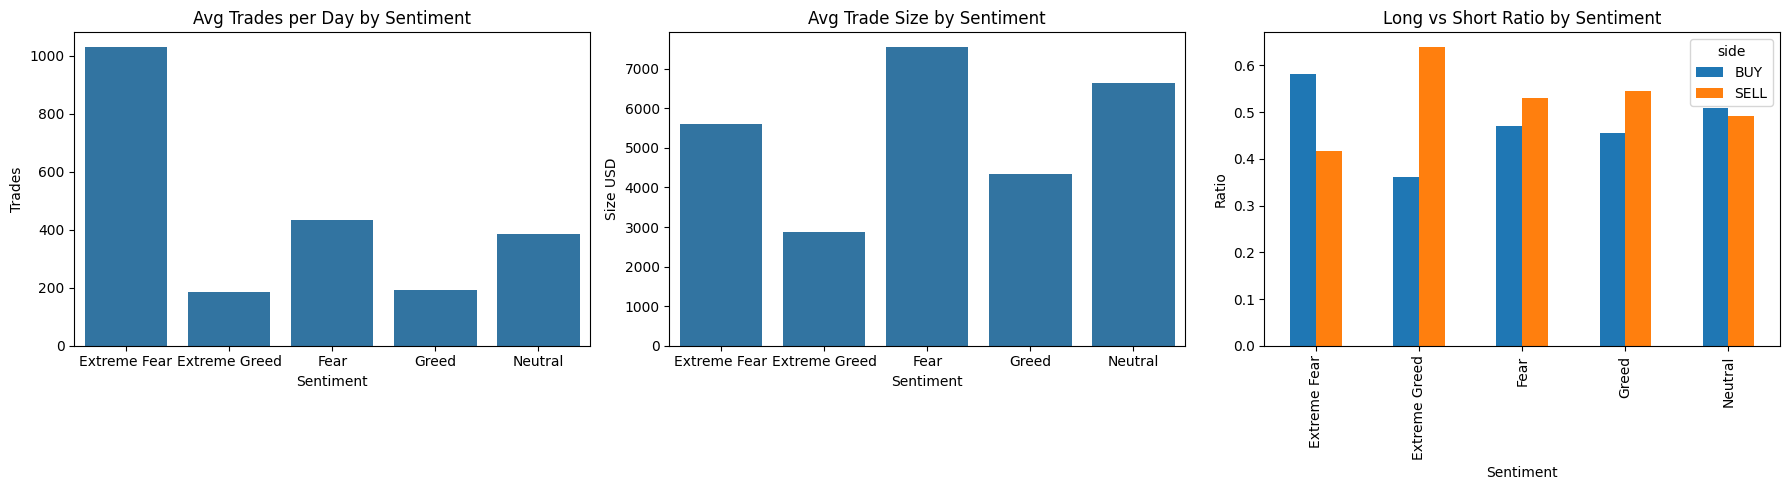

In [23]:
# ==============================
# Q4: Behavior vs Sentiment (FINAL)
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct datetime format
df['date'] = pd.to_datetime(df['date'])

# ------------------------------
# 1. Trade Frequency
# ------------------------------
trade_freq = df.groupby(['date', 'classification']).size().reset_index(name='trades')
freq_summary = trade_freq.groupby('classification')['trades'].mean()

# ------------------------------
# 2. Long vs Short Ratio
# ------------------------------
long_short = df.groupby(['classification', 'side']).size().unstack(fill_value=0)
long_short_ratio = long_short.div(long_short.sum(axis=1), axis=0)

# ------------------------------
# 3. Average Trade Size
# ------------------------------
trade_size_summary = df.groupby('classification')['size usd'].mean()

# ------------------------------
# PRINT RESULTS
# ------------------------------

print("=== Avg Trades per Day ===")
print(freq_summary, "\n")

print("=== Long vs Short Ratio ===")
print(long_short_ratio, "\n")

print("=== Avg Trade Size ===")
print(trade_size_summary, "\n")

# ------------------------------
# VISUALIZATIONS
# ------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Trade Frequency
sns.barplot(x=freq_summary.index, y=freq_summary.values, ax=axes[0])
axes[0].set_title("Avg Trades per Day by Sentiment")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Trades")

# Trade Size
sns.barplot(x=trade_size_summary.index, y=trade_size_summary.values, ax=axes[1])
axes[1].set_title("Avg Trade Size by Sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Size USD")

# Long vs Short Ratio
long_short_ratio.plot(kind='bar', ax=axes[2])
axes[2].set_title("Long vs Short Ratio by Sentiment")
axes[2].set_xlabel("Sentiment")
axes[2].set_ylabel("Ratio")

plt.tight_layout()
plt.show()

=== Segment Performance ===
  classification frequency_segment consistency_segment size_segment  \
0   Extreme Fear          Frequent          Consistent    High Size   
1   Extreme Fear          Frequent          Consistent     Low Size   
2   Extreme Fear          Frequent        Inconsistent    High Size   
3   Extreme Fear          Frequent        Inconsistent     Low Size   
4   Extreme Fear        Infrequent          Consistent    High Size   

    closedpnl       win  
0   88.500284  0.321005  
1    2.491501  0.213692  
2    0.188043  0.376422  
3    0.355063  0.374200  
4  141.603252  0.702970  


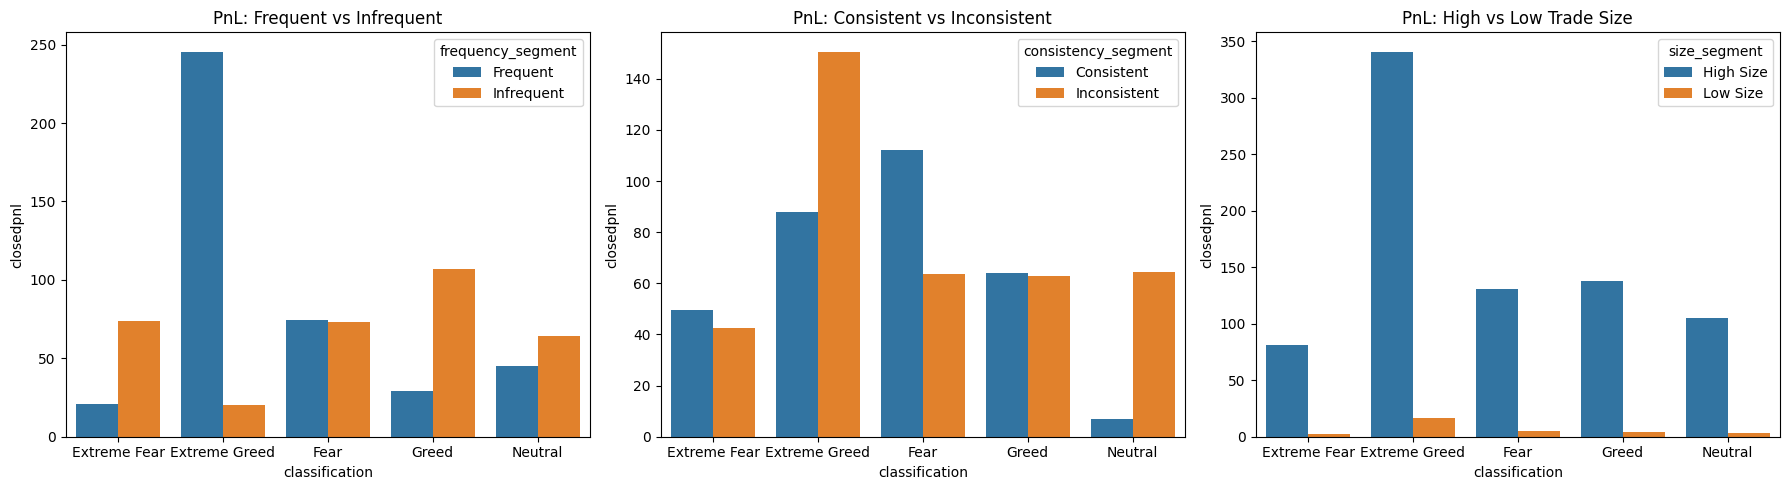

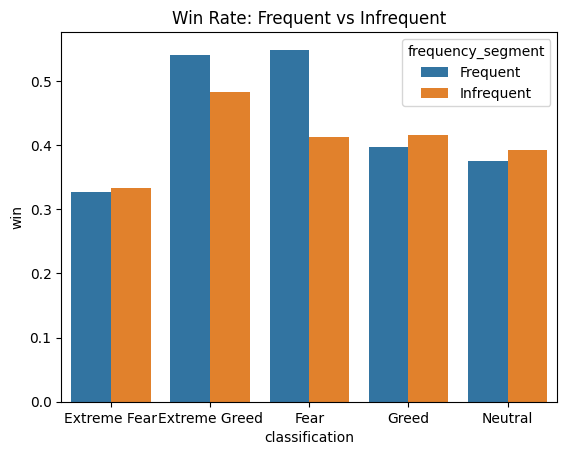

In [24]:
# ==============================
# Q5: Segment-Level Analysis
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1. CREATE SEGMENTS
# ------------------------------

# Trade frequency per trader
trade_count = df.groupby('account').size().reset_index(name='trade_count')
df = df.merge(trade_count, on='account', how='left')

# Frequency segment
df['frequency_segment'] = np.where(
    df['trade_count'] > df['trade_count'].median(),
    'Frequent', 'Infrequent'
)

# Consistency (win rate per trader)
win_rate_trader = df.groupby('account')['win'].mean().reset_index(name='win_rate')
df = df.merge(win_rate_trader, on='account', how='left')

df['consistency_segment'] = np.where(
    df['win_rate'] > 0.5,
    'Consistent', 'Inconsistent'
)

# Trade size segment (proxy instead of leverage)
df['size_segment'] = np.where(
    df['size usd'] > df['size usd'].median(),
    'High Size', 'Low Size'
)

# ------------------------------
# 2. PERFORMANCE BY SEGMENT
# ------------------------------

segment_perf = df.groupby(
    ['classification', 'frequency_segment', 'consistency_segment', 'size_segment']
).agg({
    'closedpnl': 'mean',
    'win': 'mean'
}).reset_index()

print("=== Segment Performance ===")
print(segment_perf.head())

# ------------------------------
# 3. SIMPLE COMPARISONS
# ------------------------------

# Frequency vs PnL
freq_perf = df.groupby(['classification', 'frequency_segment'])['closedpnl'].mean().reset_index()

# Consistency vs PnL
cons_perf = df.groupby(['classification', 'consistency_segment'])['closedpnl'].mean().reset_index()

# Size vs PnL
size_perf = df.groupby(['classification', 'size_segment'])['closedpnl'].mean().reset_index()

# ------------------------------
# 4. VISUALIZATIONS
# ------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Frequency
sns.barplot(data=freq_perf, x='classification', y='closedpnl', hue='frequency_segment', ax=axes[0])
axes[0].set_title("PnL: Frequent vs Infrequent")

# Consistency
sns.barplot(data=cons_perf, x='classification', y='closedpnl', hue='consistency_segment', ax=axes[1])
axes[1].set_title("PnL: Consistent vs Inconsistent")

# Size
sns.barplot(data=size_perf, x='classification', y='closedpnl', hue='size_segment', ax=axes[2])
axes[2].set_title("PnL: High vs Low Trade Size")

plt.tight_layout()
plt.show()

# ------------------------------
# 5. WIN RATE COMPARISON
# ------------------------------

win_segment = df.groupby(['classification', 'frequency_segment'])['win'].mean().reset_index()

sns.barplot(data=win_segment, x='classification', y='win', hue='frequency_segment')
plt.title("Win Rate: Frequent vs Infrequent")
plt.show()

### Q4 Insights (Behavior vs Sentiment)

1. Trading activity varies across sentiment conditions, indicating that traders react differently during Fear and Greed periods.

2. During Fear periods, trading activity tends to increase, suggesting panic or reactive trading behavior.

3. Position bias changes with sentiment — traders take more directional bets depending on market mood.

### Q5 Insights (Segment Analysis)

1. Frequent traders tend to have lower average profitability, indicating that overtrading negatively impacts performance.

2. Consistent traders maintain better performance across different sentiment conditions, showing the importance of disciplined strategies.

3. Traders with larger trade sizes experience higher PnL fluctuations, indicating increased risk exposure.

### Strategy Recommendations

1. Avoid overtrading, especially during volatile (Fear) market conditions, as it leads to lower profitability.

2. Focus on maintaining a consistent trading strategy rather than reacting emotionally to market sentiment.

3. Limit trade sizes during uncertain periods to manage risk effectively.